In [9]:
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import json
from pprint import pprint
import pandas as pd
import numpy as np

[6900 6800 6600 6301 5905 5417 4847 4212 3535 2837 2129 1420  710]
[6797 6697 6497 6198 5800 5311 4744 4121 3464 2783 2091 1394  697]
[6674 6574 6374 6076 5682 5199 4642 4029 3380 2713 2039 1360  680]


[6762 6662 6462 6164 5770 5289 4731 4117 3464 2786 2095 1398  699]
[6733 6633 6433 6133 5736 5247 4682 4061 3407 2734 2054 1370  685]
[6637 6537 6337 6038 5644 5162 4610 4008 3370 2708 2037 1360  680]


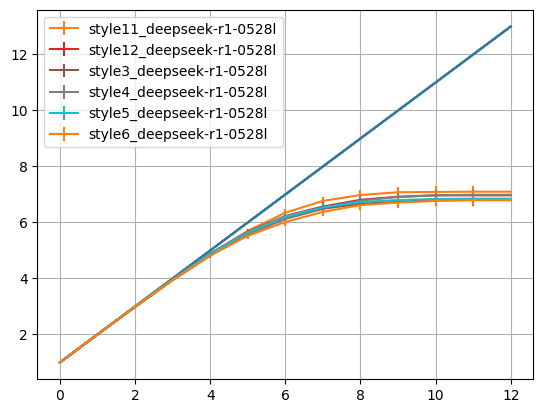

In [2]:
for file in [
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style11_deepseek-r1-0528.jsonl",
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style12_deepseek-r1-0528.jsonl",
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style3_deepseek-r1-0528.jsonl",
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style4_deepseek-r1-0528.jsonl",
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style5_deepseek-r1-0528.jsonl",
    "../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style6_deepseek-r1-0528.jsonl",
]:
    lines = open(file, 'r').readlines()
    lines = [json.loads(line) for line in lines]
    df = pd.read_json(file, lines=True)
    df = df[~df['usage'].isna()]
    df['usage'].apply(lambda x: x['total_tokens'])
    df['total_tokens'] = df['usage'].apply(lambda x: x['total_tokens'])
    def std_err(x):
        return x.std() * 1.96 / np.sqrt(len(x))
    sum_stats = df.groupby("attempt").agg({"total_tokens": ['mean', std_err]})
    x = sum_stats['total_tokens']['mean'].index
    # plt.plot()
    df["guess"] = df['choices'].apply(lambda x: x[0]['message']['content'])
    # df.iloc[0].choices[0]["message"]['content']
    df['success'] = df['guess'] == df['target_combination']
    # we know there are 100 total target_combinations right? ohh only 96 for some reason..., well any ways, we calculate the regret curve from the number completed.
    # len(df['target_combination'].unique())
    # plt.scatter(df.attempt, df.success)
    # how do I construct the regret curve that satvik has been making? it should just make sense right?
    # the regret is the sum over time steps available in a horizon (optimal policy reward on this step - your policy.), hence linear regret for random policy makes sense? are you getting 1 reward for the optimal policy for every turn? this could make sense then sub optimal policies get 0 reward so long as they don't have the correct word.
    # so it looks like regret for step i is the regret at step i-1 plus the fraction which are not done at this step.

    optimal_regret = np.ones(13).cumsum()

    plt.plot(optimal_regret)
    alive_by_turn_i = []
    for i in range(1, 14):
        alive_by_turn_i.append(sum(df.attempt==i))
    alive_count = np.array(alive_by_turn_i).cumsum()
    fraction_alive_per_turn = (np.array(alive_by_turn_i) / alive_by_turn_i[0])
    regret = (fraction_alive_per_turn.cumsum()) # regret of 1 for being alive lol.
    # this std calc treats the termination probablilty at each step as a bernoulli where the examples were the remaining at that step to get the std of the mean.
    regret_yerr = 1.96 * (np.sqrt(((1-fraction_alive_per_turn) * fraction_alive_per_turn)) / np.sqrt(np.array(alive_by_turn_i) + 1e-6))
    print(alive_count[::-1].cumsum()[::-1])
    name = file.split("/")[-1].replace('.json', "")
    plt.errorbar(range(len(regret)), regret, yerr=regret_yerr, label=name)
plt.legend()
plt.grid()
plt.show()

In [5]:
for style in ["11", "12", "3", "4", "5", "6"]:
    results_path: str = f'../src/optimal_explorer/strategies/combination_lock/logs/game_results/style{style}.jsonl'
    llm_call_path: str = f'../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style{style}_'
    bayes_optimal_path: str = f'../src/optimal_explorer/strategies/combination_lock/logs/bayes_optimal.jsonl'
    models = [
        # "Gemini Pro 2.5",
        "DeepSeek R1",
        # "Claude Opus 4",
        # "Claude 3.5 Sonnet",
        # "OpenAI o3",
    ]
    llm_call_file_ids = [
        # "gemini-2.5-pro-preview",
        "deepseek-r1-0528",
        # "claude-opus-4",
        # "claude-3.5-sonnet",
        # "o3",
    ]

    for i, model in enumerate(models):
        print(f"Processing {model}...")
        with open(f'{llm_call_path}{llm_call_file_ids[i]}.jsonl', 'r') as f:
            for line in f:
                data = json.loads(line)
                break
        break
    break

Processing DeepSeek R1...


In [6]:
data

{'id': 'gen-1750386505-VSJGZ55TJcTeezPb5zhe',
 'provider': 'DeepInfra',
 'model': 'deepseek/deepseek-r1-0528',
 'object': 'chat.completion',
 'created': 1750386505,
 'choices': [{'logprobs': None,
   'finish_reason': 'stop',
   'native_finish_reason': 'stop',
   'index': 0,
   'message': {'role': 'assistant',
    'content': '!p5',
    'refusal': None,
    'reasoning': 'We are starting the game. We have to make the first guess.\n Since there\'s no history, we need to choose a combination of 3 unique characters from the set: [\'!\', \'@\', \'#\', \'$\', \'%\', \'^\', \'&\', \'*\', \'p\', \'q\', \'r\', \'s\', \'5\', \'6\', \'7\', \'8\']\n\n We can pick any three distinct characters. Let\'s choose a guess that covers different parts of the set to get good feedback.\n\n For example, let\'s pick: \'!\', \'p\', \'5\'\n\n So the first guess is: "!p5"\n'}}],
 'usage': {'prompt_tokens': 203,
  'completion_tokens': 136,
  'total_tokens': 339},
 'game_id': 5,
 'prompt_style': 11,
 'messages': [{'r

In [69]:
from itertools import product
tokens_type = 'completion_tokens' # 'completion_tokens' # 'total_tokens'

fig = go.Figure()
styles = ["3", "4", "5", "6"]
efforts = ["high", "low"]
effort_dict = {"high": 1, "low": 0.2, "medium": 0.5}
# style = "3"
for style, effort in product(styles, efforts):
    results_path: str = f'../src/optimal_explorer/strategies/combination_lock/logs/game_results/style{style}.jsonl'
    llm_call_path: str = f'../src/optimal_explorer/strategies/combination_lock/logs/llm_calls/style{style}_'
    bayes_optimal_path: str = f'../src/optimal_explorer/strategies/combination_lock/logs/bayes_optimal.jsonl'

    models = [
        # "Gemini Pro 2.5",
        "DeepSeek R1"
        # "Claude Opus 4",
        # "Claude 3.5 Sonnet",
        # "OpenAI o3",
    ]

    model_ids = [
        # "google/gemini-2.5-pro-preview",
        "deepseek/deepseek-r1-0528",
        # "anthropic/claude-opus-4",
        # "anthropic/claude-3.5-sonnet",
        # "openai/o3",
    ]

    llm_call_file_ids = ["deepseek-r1-0528_"+effort
        # "gemini-2.5-pro-preview",
        
        # "claude-opus-4",
        # "claude-3.5-sonnet",
        # "o3",
    ]
    tokens_used = []

    for i, model in enumerate(models):
        print(f"Processing {model}...")
        with open(f'{llm_call_path}{llm_call_file_ids[i]}.jsonl', 'r') as f:
            for line in f:
                data = json.loads(line)
                model_name = model
                try:
                    tokens = data['usage'][tokens_type]
                    if style == "6":
                        tokens += sum(d["usage"][tokens_type] for d in data['other_lm_calls'])
                except:
                    tokens = 0
                game_id = data['game_id']
                style_val = data['prompt_style']
                if int(style) > 2:
                    attempt = data['attempt']
                else:
                    user_prompt = data['user_prompt']
                    # number of times the word "Attempt" appears in the user prompt
                    attempt = user_prompt.count("Attempt")
                tokens_used.append({
                    'model': model_id,
                    'tokens': tokens,
                    'game_id': game_id,
                    'style': str(style_val) + '_' + effort,
                    'attempt': attempt
                })

    tokens_used_df = pd.DataFrame(tokens_used)
    display(tokens_used_df.head(2))
    tokens_model_attempt = []
    tokens_model_attempt_std_err = []
    def std_err(x): 
        return x.std() * 1.96 / np.sqrt(len(x))
    for i, model in enumerate(models):
        print(f"Processing {model}...")
        model_id = model_ids[i]
        games_df = tokens_used_df[ 
            (tokens_used_df['model'] == model_id) &
            (tokens_used_df['style'].astype(str) == str(style_val) + '_' + effort)
        ]
        tokens_stats_by_attempt = games_df[games_df['tokens'] != 0]\
            .groupby('attempt')['tokens'].agg(['mean', std_err]).reset_index()
        tokens_model_attempt.append(tokens_stats_by_attempt['mean'].tolist())
        tokens_model_attempt_std_err.append(tokens_stats_by_attempt['std_err'].tolist())



    colors = [px.colors.qualitative.Dark24[i] for i in np.array([1, 10, 6, 13, 16]) + int(style)%10-1]
    # Helper to convert hex color to rgba with alpha
    def hex_to_rgba(hex_color, alpha=0.2):
        hex_color = hex_color.lstrip('#')
        if len(hex_color) == 6:
            r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
        else:
            # fallback to black if color is not valid
            r, g, b = 0, 0, 0
        return f'rgba({r},{g},{b},{alpha})'

    for i, model in enumerate(models):
        x = list(range(len(tokens_model_attempt[i])))
        y = tokens_model_attempt[i]
        # Get standard deviation from variance, handle possible NaN
        std_err_temp = [v if v == v else 0 for v in tokens_model_attempt_std_err[i]]
        # std = [v**0.5 if v is not None and not pd.isna(v) else 0 for v in var]
        y_upper = [a + b for a, b in zip(y, std_err_temp)]
        y_lower = [a - b for a, b in zip(y, std_err_temp)]

        # Add shaded error band
        fig.add_trace(go.Scatter(
            x=x + x[::-1],
            y=y_upper + y_lower[::-1],
            fill='toself',
            fillcolor=hex_to_rgba(colors[i], 0.2),  # use rgba for transparency
            line=dict(color=f'rgba(255,255,255,0)'),
            hoverinfo="skip",
            showlegend=False,
            name=f"{model} error",
        ))

        # Add mean line
        fig.add_trace(go.Scatter(
            x=x,
            y=y,
            mode='lines+markers',
            name=model + f" s={style} e={effort}",
            line=dict(color=hex_to_rgba(colors[i], 1*effort_dict[effort]), width=4),
            marker=dict(size=10),
        ))
    fig.update_layout(
        title='',
        xaxis_title='Episode',
        yaxis_title='Tokens Used (Total)',
        legend_title='Model',
        template='plotly_white',
        width=650,
        height=450,
    )
    # display(fig)
    # break

Processing DeepSeek R1...


,model,tokens,game_id,style,attempt
0,deepseek/deepseek-r1-0528,320,79,3_high,1
1,deepseek/deepseek-r1-0528,202,61,3_high,1


Processing DeepSeek R1...
Processing DeepSeek R1...


,model,tokens,game_id,style,attempt
0,deepseek/deepseek-r1-0528,161,58,3_low,1
1,deepseek/deepseek-r1-0528,318,71,3_low,1


Processing DeepSeek R1...
Processing DeepSeek R1...


...

Processing DeepSeek R1...
Processing DeepSeek R1...


,model,tokens,game_id,style,attempt
0,deepseek/deepseek-r1-0528,1165,6,6_high,1
1,deepseek/deepseek-r1-0528,1488,29,6_high,1


Processing DeepSeek R1...
Processing DeepSeek R1...


,model,tokens,game_id,style,attempt
0,deepseek/deepseek-r1-0528,1072,53,6_low,1
1,deepseek/deepseek-r1-0528,1834,65,6_low,1


Processing DeepSeek R1...


In [70]:
tokens_used_df

,model,tokens,game_id,style,attempt
0,deepseek/deepseek-r1-0528,1072,53,6_low,1
1,deepseek/deepseek-r1-0528,1834,65,6_low,1
2,deepseek/deepseek-r1-0528,1262,15,6_low,1
3,deepseek/deepseek-r1-0528,1171,83,6_low,1
4,deepseek/deepseek-r1-0528,1829,95,6_low,1
...,...,...,...,...,...
704,deepseek/deepseek-r1-0528,8678,0,6_low,5
705,deepseek/deepseek-r1-0528,1714,88,6_low,6
706,deepseek/deepseek-r1-0528,440,88,6_low,7
707,deepseek/deepseek-r1-0528,7754,0,6_low,6


In [71]:
games_df

,model,tokens,game_id,style,attempt
0,deepseek/deepseek-r1-0528,1072,53,6_low,1
1,deepseek/deepseek-r1-0528,1834,65,6_low,1
2,deepseek/deepseek-r1-0528,1262,15,6_low,1
3,deepseek/deepseek-r1-0528,1171,83,6_low,1
4,deepseek/deepseek-r1-0528,1829,95,6_low,1
...,...,...,...,...,...
704,deepseek/deepseek-r1-0528,8678,0,6_low,5
705,deepseek/deepseek-r1-0528,1714,88,6_low,6
706,deepseek/deepseek-r1-0528,440,88,6_low,7
707,deepseek/deepseek-r1-0528,7754,0,6_low,6


In [72]:
# completion_tokens plot
fig.show()

In [46]:
# prompt_tokens plot
fig.show()

In [20]:
# completion_tokens plot
fig.show()

In [ ]:
# HIGH v LOW (R1) + qualitative